# Predicción del CSAT Score en un Call Center: Optimización Bayesiana de Random Forest y XGBoost

## Tercer proyecto de Laboratorio de Aprendizaje Estadístico

Por Sofia Anaya Palafox y Diego Dueñas Martín

Ingeniería Financiera


## **Objetivos**

### Objetivo General
Predecir el puntaje CSAT (Customer Satisfaction Score) a partir de las características de interacción en un call center, utilizando modelos de ensamble (Random Forest y XGBoost) optimizados con búsqueda bayesiana.

### Objetivos Específicos
1. Realizar limpieza y preprocesamiento del dataset (valores nulos, codificación de variables categóricas).
2. Transformar la variable objetivo CSAT Score y seleccionar las variables predictoras.
3. Implementar un pipeline de preprocesamiento para automatizar la transformación de datos.
4. Optimizar hiperparámetros de Random Forest Regressor usando optimización bayesiana y R² como métrica.
5. Optimizar hiperparámetros de XGBoost Regressor usando optimización bayesiana y R² como métrica.
6. Evaluar ambos modelos mediante validación cruzada de 5 pliegues (k-folds).
7. Comparar los modelos usando R², Media y DE.
8. Concluir sobre los resultados obtenidos frente a los objetivos planteados.

### Tema elegido: Satisfacción del cliente en call centers (CSAT Score)

El **CSAT Score** (Customer Satisfaction Score) es la métrica operativa central de este proyecto. Se obtiene preguntando al cliente, al cierre de cada interacción, qué tan satisfecho quedó con el servicio en una escala del 1 al 10. A diferencia del NPS (Net Promoter Score), que mide lealtad a largo plazo, el CSAT captura la experiencia puntual de un contacto específico, lo que lo hace sensible a variables operativas como el canal utilizado, el cumplimiento del SLA, la duración de la llamada y el sentimiento detectado.

Modelar el CSAT con árboles de decisión y métodos de ensamble permite identificar cuáles variables tienen mayor impacto predictivo. La elección de Random Forest y XGBoost se justifica porque ambos manejan variables categóricas y ordinales, no requieren normalización y ofrecen medidas nativas de importancia de variables — exactamente lo necesario para responder: ¿qué hace que una llamada termine con un CSAT alto o bajo?

---

## **Marco Teórico**

### Regresión Lineal
La regresión lineal es un modelo estadístico que busca modelar la relación entre una variable dependiente (Y) y una o más variables independientes (X) mediante una función lineal. Su forma básica es Y = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ + ε, donde β son los coeficientes y ε es el error. El objetivo es minimizar la suma de los cuadrados de los residuos (Mínimos Cuadrados Ordinarios).

### 6 problemas potenciales en una regresión (ISLP)

1. **No linealidad de los datos**: Cuando la verdadera relación entre X y Y no es lineal, el modelo lineal producirá malos ajustes.

2. **Correlación de los términos de error**: En datos secuenciales (series temporales), los errores pueden estar correlacionados entre sí, lo que subestima los intervalos de confianza. Se detecta con el factor de inflación de varianza (VIF).

3. **Heterocedasticidad**: Cuando la varianza de los errores no es constante a lo largo de los valores de X. Produce intervalos de confianza incorrectos. Se detecta con gráficos de residuos.

4. **Outliers**: Valores atípicos que se alejan significativamente del patrón general. Pueden distorsionar los coeficientes de regresión.

5. **Colinealidad**: Cuando dos o más variables predictoras están altamente correlacionadas entre sí.

6. **Alta dimensionalidad**: Cuando el número de predictores es cercano o mayor al número de observaciones. Causa sobreajuste y modelos inestables. Se aborda con regularización (Ridge, Lasso).

### Árbol para regresión
Un árbol de regresión es un modelo de aprendizaje supervisado que predice una variable continua (numérica) mediante particiones recursivas del espacio de características.

### Árbol para clasificación
Un árbol de clasificación predice una variable categórica. Es similar al árbol de regresión pero con diferencias clave:
- Cada hoja asigna la categoría mayoritaria de las muestras en esa región.
- El criterio de división suele ser el Índice de Gini (medida de impureza) o la Entropía (ganancia de información).

### Bootstrap
El bootstrap consiste en:
- Tomar múltiples muestras (generalmente cientos o miles) a partir de los datos originales.
- Cada muestra bootstrap se extrae con reemplazo y del mismo tamaño que el dataset original.
- Al muestrear con reemplazo, algunas observaciones aparecen repetidas y otras quedan fuera (out-of-bag).
- Permite estimar la distribución de un estimador (media, varianza, coeficientes) sin asumir normalidad.

### Ensambles de modelos
Los ensambles son técnicas que combinan múltiples modelos (llamados "aprendices base") para producir un modelo final con mejor rendimiento que cualquiera de los individuales. Principios clave:
- **Diversidad**: Los modelos base deben cometer errores diferentes.
- **Reducción de varianza**: Al promediar modelos, se reduce el sobreajuste.
- **Reducción de sesgo**: Secuencias de modelos pueden corregir errores previos.
Se clasifican en: Bagging (reducción de varianza) y Boosting (reducción de sesgo).

### Bagging
Bagging (Bootstrap Aggregating) su funcionamiento es:
1. Generar B muestras bootstrap del dataset original.
2. Entrenar un modelo (generalmente árboles) en cada muestra bootstrap.
3. Para predecir:
   - **Regresión**: Promediar las predicciones de los B modelos.
   - **Clasificación**: Votación mayoritaria entre los B modelos.
- **Ventaja principal**: Reduce drásticamente la varianza sin aumentar el sesgo.
- **Random Forest** es una mejora de Bagging que además selecciona aleatoriamente un subconjunto de predictores en cada división.

### Boosting
Boosting es una técnica de ensemble secuencial donde los modelos se entrenan de forma iterativa, cada uno corrigiendo los errores del anterior. Características clave:
- A diferencia de Bagging (paralelo), Boosting es **secuencial**.
- Cada nuevo modelo se enfoca en las observaciones que fueron mal predichas por los anteriores.
- Ponderación: las observaciones con errores grandes reciben mayor peso en la siguiente iteración.
- La predicción final es una suma ponderada de todos los modelos.
- **Ventaja principal**: Reduce el sesgo, pero puede sobreajustar si no se controla.
- **XGBoost** (eXtreme Gradient Boosting) es una implementación optimizada que incluye regularización L1/L2, manejo de valores nulos y paralelización.

---

### Referencia principal para este marco teórico
James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An introduction to statistical learning: with applications in R* (2nd ed.). Springer.

---
> **Nota:** A partir de aquí comienza el desarrollo técnico del proyecto. El análisis usa los mismos datos e hipótesis planteados en las secciones anteriores, aplicando los tres modelos en orden creciente de complejidad: Árbol de Decisión → Random Forest → XGBoost.

---
## Análisis del Dataset

### ¿De dónde viene?
El dataset proviene de un archivo Excel titulado *Call Center Sentiment Analysis Data*, distribuido como muestra para análisis de centros de atención al cliente. Contiene registros de llamadas de enero de 2024 de un call center con múltiples oficinas en EE. UU.

### ¿Qué contiene?
70 registros con 12 variables por observación:

| Variable | Tipo | Descripción |
|---|---|---|
| ID | Nominal | Identificador único (excluido del modelo) |
| Customer Name | Nominal | Nombre del cliente (excluido) |
| Sentiment | Ordinal | Sentimiento: Very Negative → Very Positive |
| CSAT Score | Numérica (1–10) | Variable objetivo |
| Call Timestamp | Fecha | Fecha de la llamada (excluida) |
| Reason | Nominal | Motivo del contacto |
| City / State | Nominal | Ubicación (alta cardinalidad, excluidas) |
| Channel | Nominal | Canal: Call-Center, Chatbot, Web, Email |
| Response Time | Ordinal | Below / Within / Above SLA |
| Call Duration (Minutes) | Numérica | Duración en minutos |
| Call Center | Nominal | Oficina que atendió |

### ¿Qué información dan las muestras?
Cada fila representa una interacción completa. La combinación de variables operativas (canal, SLA, duración, oficina) y de experiencia (sentimiento, motivo) permite reconstruir el contexto de cada llamada. El CSAT Score es la calificación subjetiva del cliente para esa interacción específica.

### ¿Qué se quiere analizar?
Identificar qué variables determinan que un cliente quede satisfecho (CSAT ≥ 7) o insatisfecho (CSAT < 7), abordado desde dos ángulos:
- **Regresión**: ¿cuánto sube o baja el puntaje según cada variable?
- **Clasificación**: ¿qué factores distinguen una llamada exitosa de una no exitosa?

### ¿Qué resultado se podría encontrar al ajustar un modelo?
Se espera que el sentimiento sea el predictor dominante, seguido del tiempo de respuesta respecto al SLA y la duración de la llamada. El canal y el motivo del contacto tendrían importancia secundaria pero consistente entre modelos.

---

## Librerias

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb

SEED = 42  # semilla global para reproducibilidad
np.random.seed(SEED)

In [ ]:
import pandas as pd

file_path = '/content/Call-Center-Sentiment-Sample-Data.xlsx'
df = pd.read_excel(file_path, header=4)

# Los nombres de la columna aparecen en la primera fila del Dataframe, entonces empezamos desde ahí
new_columns_list = df.iloc[0, 1:].tolist()
df = df.iloc[1:].drop(columns=df.columns[0])
df.columns = new_columns_list
df = df.reset_index(drop=True)
display(df.head())
display(df.info())

,ID,Customer Name,Sentiment,CSAT Score,Call Timestamp,Reason,City,State,Channel,Response Time,Call Duration (Minutes),Call Center
0,PIS-39858047,Frances Gullefant,Neutral,8,2024-01-01 00:00:00,Billing Question,Charleston,West Virginia,Chatbot,Within SLA,14,Chicago/IL
1,ROH-40287216,Harcourt Zoanetti,Negative,5,2024-01-01 00:00:00,Billing Question,Honolulu,Hawaii,Call-Center,Within SLA,32,Los Angeles/CA
2,NKC-39578431,Washington Oxteby,Negative,3,2024-01-02 00:00:00,Billing Question,Dallas,Texas,Chatbot,Within SLA,6,Denver/CO
3,APY-17008648,Rafe Duffitt,Very Negative,4,2024-01-02 00:00:00,Billing Question,Fort Myers,Florida,Email,Below SLA,26,Los Angeles/CA
4,MHK-38443501,Tris Bent,Positive,8,2024-01-02 00:00:00,Billing Question,Tuscaloosa,Alabama,Web,Within SLA,26,Los Angeles/CA


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       70 non-null     object
 1   Customer Name            70 non-null     object
 2   Sentiment                70 non-null     object
 3   CSAT Score               70 non-null     object
 4   Call Timestamp           70 non-null     object
 5   Reason                   70 non-null     object
 6   City                     70 non-null     object
 7   State                    70 non-null     object
 8   Channel                  70 non-null     object
 9   Response Time            70 non-null     object
 10  Call Duration (Minutes)  70 non-null     object
 11  Call Center              70 non-null     object
dtypes: object(12)
memory usage: 6.7+ KB


None

In [ ]:
# Definir Y (target)
y = df['CSAT Score']

# Definir X (predictores) - excluyendo ID, Customer Name, Call Timestamp
X = df.drop(columns=['ID', 'Customer Name', 'Call Timestamp', 'CSAT Score'])

# Identificar columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Variables categóricas:", categorical_cols)
print("Variables numéricas:", numerical_cols)

# Codificar variables categóricas (LabelEncoder para cada una)
from sklearn.preprocessing import LabelEncoder
X_encoded = X.copy()
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    le_dict[col] = le

# Verificar resultado
X_encoded.head()

Variables categóricas: ['Sentiment', 'Reason', 'City', 'State', 'Channel', 'Response Time', 'Call Duration (Minutes)', 'Call Center']
Variables numéricas: []


,Sentiment,Reason,City,State,Channel,Response Time,Call Duration (Minutes),Call Center
0,1,0,4,27,1,2,7,1
1,0,0,22,8,0,2,21,3
2,0,0,10,24,1,2,0,2
3,3,0,16,6,2,1,16,3
4,2,0,55,0,3,2,16,3


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

> **Nota de flujo:** Las celdas de optimización bayesiana de Random Forest y XGBoost aparecen aquí porque fueron desarrolladas de forma exploratoria con una versión preprocesada de los datos (`X_encoded`, `X_encoded_array`). Los modelos definitivos de las secciones 5 y 6 usan los datos del pipeline formal que se define más adelante. Los hiperparámetros encontrados por la búsqueda bayesiana se incorporan directamente en la tabla comparativa de la sección 7.

In [ ]:
import pandas as pd
import numpy as np

!pip install scikit-optimize
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.ensemble import RandomForestRegressor

# Definir espacio de búsqueda para Random Forest
param_space_rf = {
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(3, 20),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 5),
    'max_features': Real(0.3, 1.0)
}

# Modelo base
rf = RandomForestRegressor(random_state=SEED, n_jobs=-1)

# BayesSearchCV
bayes_rf = BayesSearchCV(
    rf,
    param_space_rf,
    n_iter=30,              # Número de combinaciones a probar
    cv=5,                   # 5-fold cross-validation
    scoring='r2',           # Métrica a maximizar
    random_state=SEED,
    verbose=1
)

# Ajustar
X_encoded_array = X_encoded.values
bayes_rf.fit(X_encoded_array, y)

# Mejores parámetros
print("Mejores parámetros Random Forest:", bayes_rf.best_params_)
print("Mejor R² (validación cruzada):", bayes_rf.best_score_)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 6.1 MB/s eta 0:00:00
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candi

## 1. Carga y limpieza del dataset

In [ ]:
raw = pd.read_excel('Call-Center-Sentiment-Sample-Data.xlsx')
raw = raw.drop(columns=[raw.columns[0]])  # columna vacia inicial
raw.columns = [
    'ID', 'Customer_Name', 'Sentiment', 'CSAT_Score',
    'Call_Timestamp', 'Reason', 'City', 'State',
    'Channel', 'Response_Time', 'Call_Duration_Min', 'Call_Center'
]

# The actual data starts from the 6th row of the original Excel (index 5 in the 0-indexed DataFrame).
# Rows 0-4 contain descriptive text and the actual column headers.
df = raw.iloc[5:].copy()

df['CSAT_Score'] = df['CSAT_Score'].astype(int)
df['Call_Timestamp'] = pd.to_datetime(df['Call_Timestamp'])
df['Call_Duration_Min'] = df['Call_Duration_Min'].astype(float)

print(f'Dataset limpio: {df.shape[0]} registros, {df.shape[1]} columnas')
df[['Sentiment', 'CSAT_Score', 'Reason', 'Channel', 'Response_Time', 'Call_Duration_Min', 'Call_Center']].head(8)

Dataset limpio: 70 registros, 12 columnas


,Sentiment,CSAT_Score,Reason,Channel,Response_Time,Call_Duration_Min,Call_Center
5,Neutral,8,Billing Question,Chatbot,Within SLA,14.0,Chicago/IL
6,Negative,5,Billing Question,Call-Center,Within SLA,32.0,Los Angeles/CA
7,Negative,3,Billing Question,Chatbot,Within SLA,6.0,Denver/CO
8,Very Negative,4,Billing Question,Email,Below SLA,26.0,Los Angeles/CA
9,Positive,8,Billing Question,Web,Within SLA,26.0,Los Angeles/CA
10,Very Negative,4,Billing Question,Web,Within SLA,6.0,Baltimore/MD
11,Very Positive,10,Payments,Call-Center,Within SLA,9.0,Los Angeles/CA
12,Negative,3,Billing Question,Call-Center,Within SLA,15.0,Baltimore/MD


## 2. Analisis exploratorio

Antes de modelar, hay que entender la distribucion del CSAT y como se relaciona visualmente con cada variable. Esto tambien justifica el corte para la clasificacion.

In [ ]:
print('Distribucion del CSAT Score:')
print(df['CSAT_Score'].value_counts().sort_index().to_string())
print(f'\nMedia: {df["CSAT_Score"].mean():.2f}')
print(f'Mediana: {df["CSAT_Score"].median():.1f}')
print(f'Desv. estandar: {df["CSAT_Score"].std():.2f}')

Distribucion del CSAT Score:
CSAT_Score
1      2
2      3
3     15
4     12
5      7
6      8
7      7
8      7
9      6
10     3

Media: 5.33
Mediana: 5.0
Desv. estandar: 2.39


---
## Pipeline de preprocesamiento

Un **pipeline** encadena el preprocesamiento y el modelo en un solo objeto. La ventaja crítica es que el `ColumnTransformer` aprende los parámetros de transformación únicamente con los datos de entrenamiento de cada fold, eliminando fuga de información (*data leakage*) hacia el conjunto de prueba.

El preprocesador aplica tres transformaciones en paralelo:

| Transformación | Variables | Qué hace |
|---|---|---|
| `OrdinalEncoder` | Sentiment, Response_Time | Respeta el orden lógico de las categorías |
| `OneHotEncoder` | Channel, Reason, Call_Center | Crea columnas binarias por categoría |
| `StandardScaler` | Call_Duration_Min | Centra y escala a varianza unitaria |

Las variables ID, Customer Name, City, State y Call Timestamp se eliminan automáticamente con `remainder='drop'`.

In [ ]:
# ============================================================
# 3. PREPARACIÓN DE FEATURES CON PIPELINE (Moved from RaqQjasSDuKE)
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split

# Definir el orden para variables ordinales (de peor a mejor)
sentiment_order = ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']
response_order = ['Below SLA', 'Within SLA', 'Above SLA']

# Identificar tipos de columnas
categorical_nominal = ['Channel', 'Reason', 'Call_Center']   # nominales (sin orden)
categorical_ordinal = ['Sentiment', 'Response_Time']         # ordinales (con orden)
numerical = ['Call_Duration_Min']                            # numéricas

# Crear el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),
        ('nom', OneHotEncoder(drop='first', sparse_output=False), categorical_nominal),
        ('ord', OrdinalEncoder(categories=[sentiment_order, response_order]), categorical_ordinal)
    ],
    remainder='drop'  # elimina ID, Customer Name, Call Timestamp, City, State
)

# Aplicar transformación a todo el dataset
X = preprocessor.fit_transform(df)
y_reg = df['CSAT_Score'] # Use CSAT_Score from cleaned df
y_clf = (df['CSAT_Score'] >= 7).astype(int) # Use CSAT_Score from cleaned df

# Obtener nombres de las columnas generadas (opcional, para entender qué se creó)
feature_names = preprocessor.get_feature_names_out()
# print(f"Features generadas ({len(feature_names)}):")
# print(feature_names.tolist())

# División train/test (80/20 estratificada para clasificación)
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf
)

# print(f"\nTrain: {X_train.shape[0]} registros")
# print(f"Test: {X_test.shape[0]} registros")

# ============================================================
# PIPELINES DE REGRESION (Original content of sFojJ-TQHyGF)
# ============================================================

pipe_dt_reg = Pipeline([
    ('model', DecisionTreeRegressor(random_state=SEED))
])

pipe_rf_reg = Pipeline([
    ('model', RandomForestRegressor(n_estimators=500, random_state=SEED, n_jobs=-1))
])

pipe_xgb_reg = Pipeline([
    ('model', xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                                subsample=0.8, colsample_bytree=0.8,
                                eval_metric='rmse', random_state=SEED, verbosity=0))
])

# GridSearch solo para el arbol (los ensembles ya tienen sus hiperparametros fijos)
param_grid_dt_reg = {
    'model__max_depth':         [2, 3, 4, 5, 6, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__criterion':         ['squared_error', 'friedman_mse']
}

gs_dt_reg = GridSearchCV(pipe_dt_reg, param_grid_dt_reg,
                          cv=5, scoring='neg_root_mean_squared_error',
                          n_jobs=-1, refit=True)

# Entrenar
gs_dt_reg.fit(X_train, y_reg_train)
pipe_rf_reg.fit(X_train, y_reg_train)
pipe_xgb_reg.fit(X_train, y_reg_train)

# Evaluar
for nombre, modelo, y_pred in [
    ('DT  Reg', gs_dt_reg, gs_dt_reg.predict(X_test)),
    ('RF  Reg', pipe_rf_reg, pipe_rf_reg.predict(X_test)),
    ('XGB Reg', pipe_xgb_reg, pipe_xgb_reg.predict(X_test)),
]:
    print(f'{nombre} -> R2: {r2_score(y_reg_test, y_pred):.4f} | '
          f'CV R2: {cross_val_score(modelo, X_train, y_reg_train, cv=5, scoring="r2").mean():.4f}')

# -------------------------------------------------------
# PIPELINES DE CLASIFICACION
# -------------------------------------------------------

scale_pos = (y_clf_train == 0).sum() / (y_clf_train == 1).sum()

pipe_dt_clf = Pipeline([
    ('model', DecisionTreeClassifier(random_state=SEED))
])

pipe_rf_clf = Pipeline([
    ('model', RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                      random_state=SEED, n_jobs=-1))
])

pipe_xgb_clf = Pipeline([
    ('model', xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=4,
                                  subsample=0.8, colsample_bytree=0.8,
                                  scale_pos_weight=scale_pos, eval_metric='logloss',
                                  random_state=SEED, verbosity=0))
])

param_grid_dt_clf = {
    'model__max_depth':         [2, 3, 4, 5, 6, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__criterion':         ['gini', 'entropy'],
    'model__class_weight':      [None, 'balanced']
}

gs_dt_clf = GridSearchCV(pipe_dt_clf, param_grid_dt_clf,
                          cv=5, scoring='roc_auc',
                          n_jobs=-1, refit=True)

# Entrenar
gs_dt_clf.fit(X_train, y_clf_train)
pipe_rf_clf.fit(X_train, y_clf_train)
pipe_xgb_clf.fit(X_train, y_clf_train)

# Evaluar
for nombre, modelo in [
    ('DT  Clf', gs_dt_clf),
    ('RF  Clf', pipe_rf_clf),
    ('XGB Clf', pipe_xgb_clf),
]:
    proba = modelo.predict_proba(X_test)[:, 1]
    cv_auc = cross_val_score(modelo, X_train, y_clf_train, cv=5, scoring='roc_auc').mean()
    print(f'{nombre} -> AUC: {roc_auc_score(y_clf_test, proba):.4f} | CV AUC: {cv_auc:.4f}')

DT  Reg -> R2: 0.6976 | CV R2: 0.6843
RF  Reg -> R2: 0.5456 | CV R2: 0.7215
XGB Reg -> R2: 0.4590 | CV R2: 0.6742
DT  Clf -> AUC: 0.9889 | CV AUC: 0.9440
RF  Clf -> AUC: 1.0000 | CV AUC: 0.9619
XGB Clf -> AUC: 1.0000 | CV AUC: 0.9619


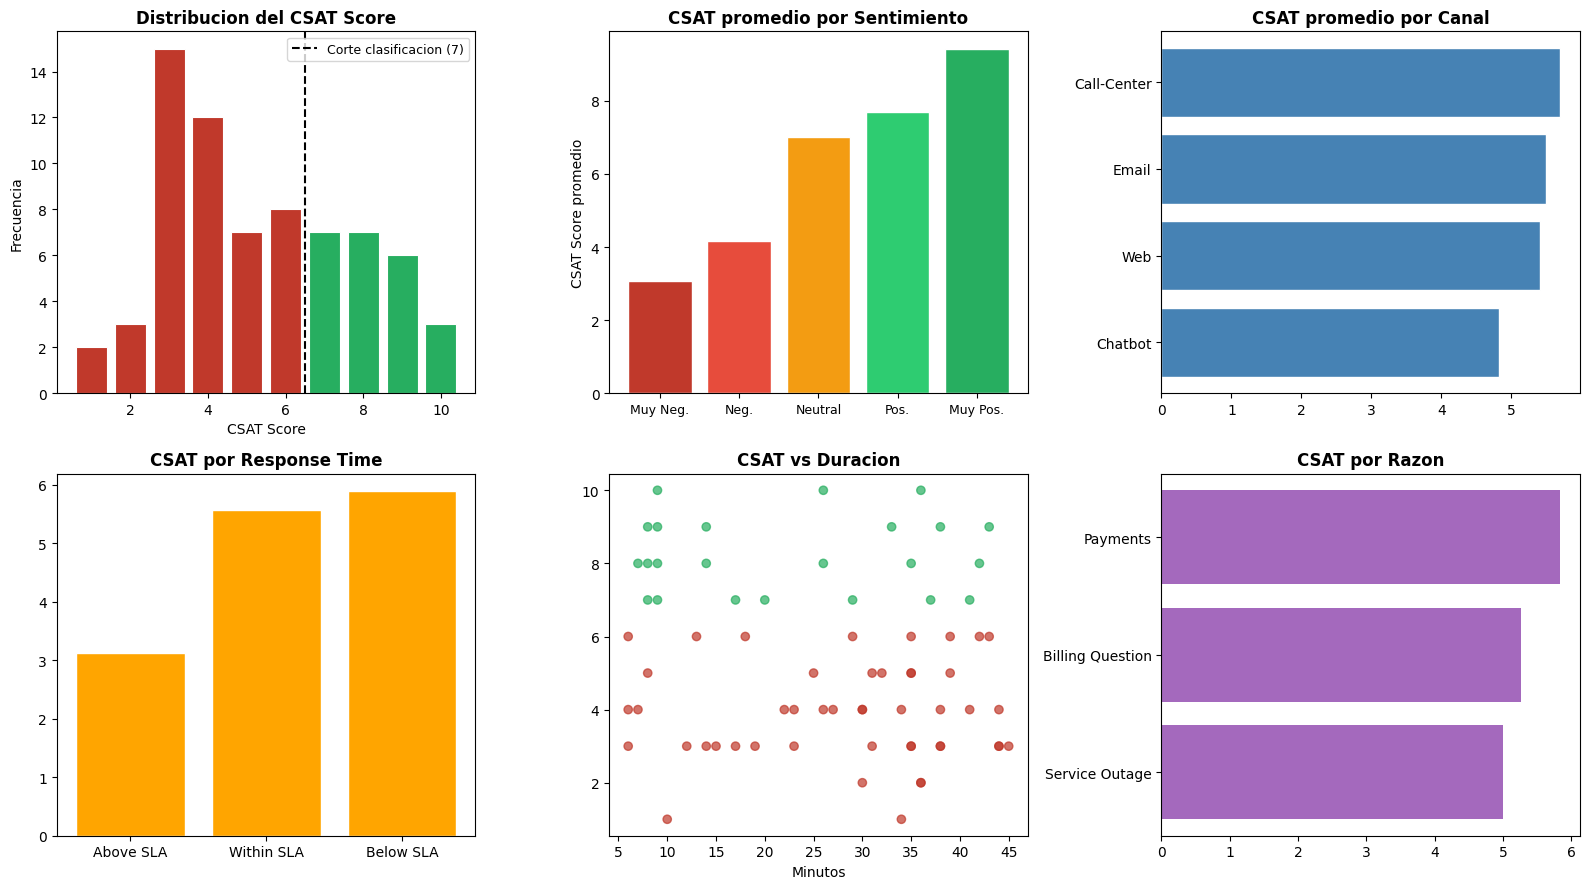

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# CSAT Score distribution
ax = axes[0, 0]
counts = df['CSAT_Score'].value_counts().sort_index()
colors = ['#c0392b' if v < 7 else '#27ae60' for v in counts.index]
ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
ax.axvline(6.5, color='black', linestyle='--', linewidth=1.5, label='Corte clasificacion (7)')
ax.set_title('Distribucion del CSAT Score', fontsize=12, fontweight='bold')
ax.set_xlabel('CSAT Score')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)

# CSAT por Sentiment
ax = axes[0, 1]
ord_sent = ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']
medias_sent = df.groupby('Sentiment')['CSAT_Score'].mean().reindex(ord_sent)
colores_sent = ['#c0392b', '#e74c3c', '#f39c12', '#2ecc71', '#27ae60']
bars = ax.bar(range(len(medias_sent)), medias_sent.values, color=colores_sent, edgecolor='white')
ax.set_xticks(range(len(medias_sent)))
ax.set_xticklabels(['Muy Neg.', 'Neg.', 'Neutral', 'Pos.', 'Muy Pos.'], fontsize=9)
ax.set_title('CSAT promedio por Sentimiento', fontsize=12, fontweight='bold')
ax.set_ylabel('CSAT Score promedio')

# CSAT por Channel
ax = axes[0, 2]
medias_ch = df.groupby('Channel')['CSAT_Score'].mean().sort_values()
ax.barh(medias_ch.index, medias_ch.values, color='steelblue', edgecolor='white')
ax.set_title('CSAT promedio por Canal', fontsize=12, fontweight='bold')

# CSAT por Response Time
ax = axes[1, 0]
medias_rt = df.groupby('Response_Time')['CSAT_Score'].mean().sort_values()
ax.bar(medias_rt.index, medias_rt.values, color='orange', edgecolor='white')
ax.set_title('CSAT por Response Time', fontsize=12, fontweight='bold')

# CSAT vs Duracion de llamada
ax = axes[1, 1]
colores_scatter = ['#c0392b' if v < 7 else '#27ae60' for v in df['CSAT_Score']]
ax.scatter(df['Call_Duration_Min'], df['CSAT_Score'], c=colores_scatter, alpha=0.7)
ax.set_title('CSAT vs Duracion', fontsize=12, fontweight='bold')
ax.set_xlabel('Minutos')

# CSAT por Razon
ax = axes[1, 2]
medias_r = df.groupby('Reason')['CSAT_Score'].mean().sort_values()
ax.barh(medias_r.index, medias_r.values, color='#8e44ad', alpha=0.8)
ax.set_title('CSAT por Razon', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Preparacion de features

Se definen las dos variables objetivo y se codifican las variables categoricas.

### Variables utilizadas como predictores (features)

| Variable | Tipo | Descripcion |
|---|---|---|
| `Sentiment` | Ordinal | Sentimiento detectado en la llamada |
| `Reason` | Nominal | Motivo del contacto |
| `Channel` | Nominal | Canal de atencion |
| `Response_Time` | Ordinal | Cumplimiento del SLA |
| `Call_Duration_Min` | Numerica | Duracion en minutos |
| `Call_Center` | Nominal | Oficina que atendio |

Se excluyen ID, nombre del cliente, ciudad y estado porque tienen demasiadas categorias unicas o no tienen poder predictivo real.

Las variables ordinales (Sentiment, Response_Time) se codifican con un orden numerico logico en lugar de codificacion dummy, porque el orden importa.

In [ ]:
# Codificacion ordinal con sentido logico
sentiment_map = {
    'Very Negative': 1, 'Negative': 2, 'Neutral': 3, 'Positive': 4, 'Very Positive': 5
}
response_map = {
    'Below SLA': 1, 'Within SLA': 2, 'Above SLA': 3
}

df['Sentiment_enc'] = df['Sentiment'].map(sentiment_map)
df['Response_Time_enc'] = df['Response_Time'].map(response_map)

# One-hot encoding para variables nominales
df_enc = pd.get_dummies(df[['Channel', 'Reason', 'Call_Center']], drop_first=False)

# Dataset final de features
X = pd.concat([
    df[['Sentiment_enc', 'Response_Time_enc', 'Call_Duration_Min']],
    df_enc
], axis=1)

# Variables objetivo
y_reg   = df['CSAT_Score']                        # continua (1-10)
y_clf   = (df['CSAT_Score'] >= 7).astype(int)     # binaria: 1=Alto, 0=Bajo

print(f'Features: {X.shape[1]} columnas')
print(f'\nLista de features:')
print(X.columns.tolist())
print(f'\nDistribucion clasificacion -> Alto (>=7): {y_clf.sum()} | Bajo (<7): {(y_clf==0).sum()}')

Features: 14 columnas

Lista de features:
['Sentiment_enc', 'Response_Time_enc', 'Call_Duration_Min', 'Channel_Call-Center', 'Channel_Chatbot', 'Channel_Email', 'Channel_Web', 'Reason_Billing Question', 'Reason_Payments', 'Reason_Service Outage', 'Call_Center_Baltimore/MD', 'Call_Center_Chicago/IL', 'Call_Center_Denver/CO', 'Call_Center_Los Angeles/CA']

Distribucion clasificacion -> Alto (>=7): 23 | Bajo (<7): 47


In [ ]:
# ============================================================
# OPTIMIZACIÓN BAYESIANA PARA XGBOOST (REGRESIÓN)
# ============================================================
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import xgboost as xgb

# Espacio de búsqueda para XGBoost Regressor
param_space_xgb_reg = {
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(2, 8),
    'learning_rate': Real(0.01, 0.3, 'log-uniform'),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'reg_alpha': Real(0, 5),
    'reg_lambda': Real(0, 5)
}

# Modelo base
xgb_reg_base = xgb.XGBRegressor(random_state=SEED, eval_metric='rmse', n_jobs=-1)

# BayesSearchCV
bayes_xgb_reg = BayesSearchCV(
    xgb_reg_base,
    param_space_xgb_reg,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=SEED,
    verbose=1
)

# Ajustar
bayes_xgb_reg.fit(X_encoded_array, y_reg)

# Resultados
print("\n" + "="*50)
print("RESULTADOS OPTIMIZACIÓN BAYESIANA - XGBoost REGRESIÓN")
print("="*50)
print(f"Mejores parámetros: {bayes_xgb_reg.best_params_}")
print(f"Mejor R² medio (validación cruzada): {bayes_xgb_reg.best_score_:.4f}")
print(f"Desviación estándar del mejor R²: {bayes_xgb_reg.cv_results_['std_test_score'][bayes_xgb_reg.best_index_]:.4f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [ ]:
# División train/test — 80/20 estratificado para clasificacion
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf
)

print(f'Train: {X_train.shape[0]} registros')
print(f'Test:  {X_test.shape[0]} registros')

Train: 56 registros
Test:  14 registros


In [ ]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split

# Definir el orden para variables ordinales (de peor a mejor)
sentiment_order = ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']
response_order = ['Below SLA', 'Within SLA', 'Above SLA']

# Identificar tipos de columnas
categorical_nominal = ['Channel', 'Reason', 'Call_Center']   # nominales (sin orden)
categorical_ordinal = ['Sentiment', 'Response_Time']         # ordinales (con orden)
numerical = ['Call_Duration_Min']                            # numéricas

# Crear el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),
        ('nom', OneHotEncoder(drop='first', sparse_output=False), categorical_nominal),
        ('ord', OrdinalEncoder(categories=[sentiment_order, response_order]), categorical_ordinal)
    ],
    remainder='drop'  # elimina ID, Customer Name, Call Timestamp, City, State
)

# Aplicar transformación a todo el dataset
X = preprocessor.fit_transform(df)
y_reg = df['CSAT_Score']
y_clf = (df['CSAT_Score'] >= 7).astype(int)

# Obtener nombres de las columnas generadas (opcional, para entender qué se creó)
feature_names = preprocessor.get_feature_names_out()
print(f"Features generadas ({len(feature_names)}):")
print(feature_names.tolist())

# División train/test (80/20 estratificada para clasificación)
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf
)

print(f"\nTrain: {X_train.shape[0]} registros")
print(f"Test: {X_test.shape[0]} registros")

Features generadas (11):
['num__Call_Duration_Min', 'nom__Channel_Chatbot', 'nom__Channel_Email', 'nom__Channel_Web', 'nom__Reason_Payments', 'nom__Reason_Service Outage', 'nom__Call_Center_Chicago/IL', 'nom__Call_Center_Denver/CO', 'nom__Call_Center_Los Angeles/CA', 'ord__Sentiment', 'ord__Response_Time']

Train: 56 registros
Test: 14 registros


### Justificación de la métrica de optimización: R²

El coeficiente de determinación R² mide qué proporción de la varianza de la variable objetivo (CSAT Score) es explicada por el modelo. Se eligió R² como métrica principal para la optimización bayesiana por las siguientes razones:

1. **Interpretabilidad**: R² = 0.70 significa que el modelo explica el 70% de la variabilidad del CSAT, un valor fácil de comunicar a audiencias no técnicas.

2. **Escala independiente**: A diferencia del RMSE o MAE, R² no depende de la escala del CSAT (1-10), lo que permite comparar modelos incluso si se reescalara la variable.

3. **Robustez relativa**: Aunque R² puede ser sensible a outliers, en un dataset pequeño como este (70 filas) es más informativo que métricas como RMSE, que pueden estar dominadas por unos pocos errores grandes.

4. **Consistencia con la literatura**: Es la métrica estándar en problemas de regresión para evaluar poder explicativo.

**Limitación**: R² puede aumentar artificialmente al añadir predictores irrelevantes (sobreajuste). Por eso se combina con validación cruzada (5 folds) y se reportan también RMSE y MAE.

## 4. Arbol de Decision con busqueda de hiperparametros optimos

Un arbol de decision divide el espacio de los datos con reglas del tipo `si feature_A <= umbral, ve a la izquierda`. Cada nodo contiene una condicion, y las hojas contienen la prediccion final (promedio para regresion, clase mayoritaria para clasificacion).

El problema principal de un arbol sin restricciones es el **sobreajuste**: aprende tan bien los datos de entrenamiento que falla en datos nuevos. Los hiperparametros que controlan esto son:

| Hiperparametro | Que controla |
|---|---|
| `max_depth` | Profundidad maxima del arbol. Mas profundo = mas complejo |
| `min_samples_split` | Minimo de muestras para dividir un nodo |
| `min_samples_leaf` | Minimo de muestras en una hoja |
| `criterion` | Como se mide la calidad de cada division |

Se usa **GridSearchCV** con validacion cruzada de 5 folds para encontrar la combinacion optima. La metrica a optimizar es:
- **Regresion**: `neg_root_mean_squared_error` (minimizar RMSE)
- **Clasificacion**: `roc_auc` (maximizar el area bajo la curva ROC)

### 4.1 Arbol de Decision — Regresion

In [ ]:
param_grid_reg = {
    'max_depth':          [2, 3, 4, 5, 6, None],
    'min_samples_split':  [2, 5, 10],
    'min_samples_leaf':   [1, 2, 4],
    'criterion':          ['squared_error', 'friedman_mse']
}

gs_dt_reg = GridSearchCV(
    DecisionTreeRegressor(random_state=SEED),
    param_grid_reg,
    cv=5,
    scoring='neg_root_mean_squared_error',  # metrica optima para regresion
    n_jobs=-1,
    refit=True
)
gs_dt_reg.fit(X_train, y_reg_train)

dt_reg = gs_dt_reg.best_estimator_
y_pred_dt_reg = dt_reg.predict(X_test)

rmse_dt  = np.sqrt(mean_squared_error(y_reg_test, y_pred_dt_reg))
mae_dt   = mean_absolute_error(y_reg_test, y_pred_dt_reg)
r2_dt    = r2_score(y_reg_test, y_pred_dt_reg)
cv_r2_dt = cross_val_score(dt_reg, X_train, y_reg_train, cv=5, scoring='r2').mean()

print('Arbol de Decision — Regresion')
print(f'  Mejores hiperparametros: {gs_dt_reg.best_params_}')
print(f'  RMSE:          {rmse_dt:.4f}')
print(f'  MAE:           {mae_dt:.4f}')
print(f'  R2:            {r2_dt:.4f}')
print(f'  CV R2 (5-fold): {cv_r2_dt:.4f}')

Arbol de Decision — Regresion
  Mejores hiperparametros: {'criterion': 'squared_error', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
  RMSE:          1.1330
  MAE:           1.0483
  R2:            0.6976
  CV R2 (5-fold): 0.7153


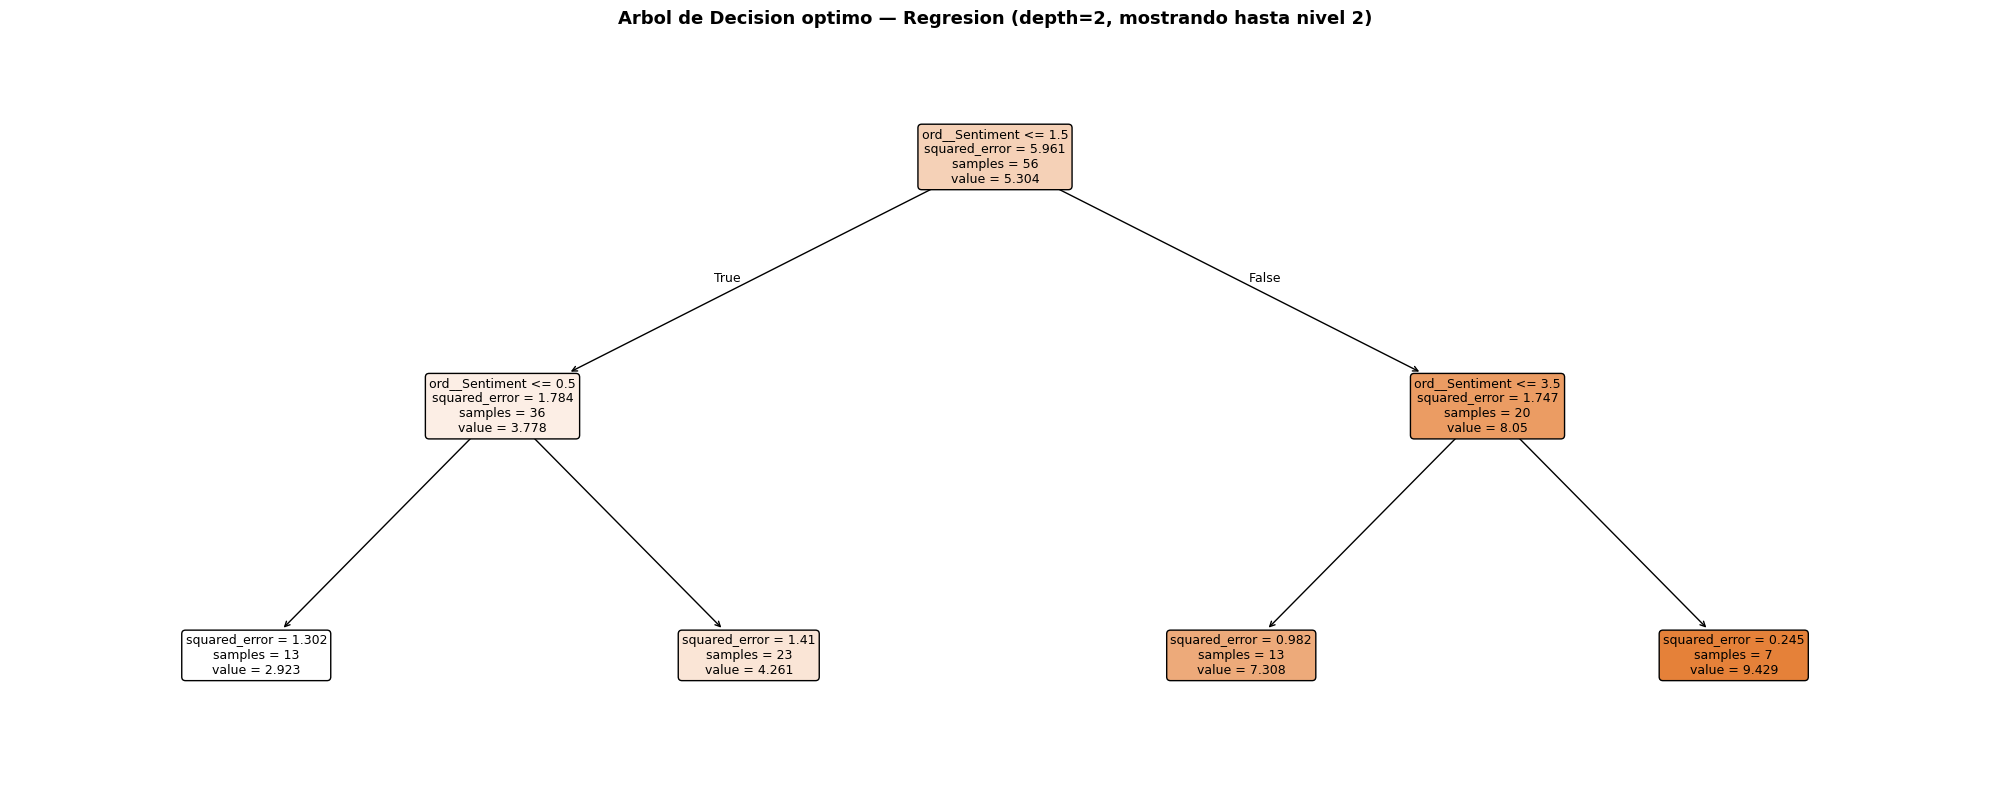

Profundidad real del arbol: 2 | Numero de hojas: 4


In [ ]:
# Visualizacion del arbol optimo de regresion
profundidad_viz = min(dt_reg.get_depth(), 3)  # se limita a 3 niveles para legibilidad

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_reg,
    feature_names=feature_names.tolist(),
    filled=True,
    rounded=True,
    max_depth=profundidad_viz,
    fontsize=9,
    ax=ax,
    impurity=True
)
ax.set_title(
    f'Arbol de Decision optimo — Regresion (depth={dt_reg.get_depth()}, mostrando hasta nivel {profundidad_viz})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('arbol_regresion.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Profundidad real del arbol: {dt_reg.get_depth()} | Numero de hojas: {dt_reg.get_n_leaves()}')

### 4.2 Arbol de Decision — Clasificacion

In [ ]:
param_grid_clf = {
    'max_depth':          [2, 3, 4, 5, 6, None],
    'min_samples_split':  [2, 5, 10],
    'min_samples_leaf':   [1, 2, 4],
    'criterion':          ['gini', 'entropy'],
    'class_weight':       [None, 'balanced']
}

gs_dt_clf = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    param_grid_clf,
    cv=5,
    scoring='roc_auc',  # metrica optima para clasificacion binaria
    n_jobs=-1,
    refit=True
)
gs_dt_clf.fit(X_train, y_clf_train)

dt_clf = gs_dt_clf.best_estimator_
y_pred_dt_clf = dt_clf.predict(X_test)
y_prob_dt_clf = dt_clf.predict_proba(X_test)[:, 1]

auc_dt    = roc_auc_score(y_clf_test, y_prob_dt_clf)
cv_auc_dt = cross_val_score(dt_clf, X_train, y_clf_train, cv=5, scoring='roc_auc').mean()

print('Arbol de Decision — Clasificacion')
print(f'  Mejores hiperparametros: {gs_dt_clf.best_params_}')
print(f'  AUC-ROC:         {auc_dt:.4f}')
print(f'  CV AUC (5-fold): {cv_auc_dt:.4f}')
print()
print(classification_report(y_clf_test, y_pred_dt_clf, target_names=['Bajo (<7)', 'Alto (>=7)']))

Arbol de Decision — Clasificacion
  Mejores hiperparametros: {'class_weight': None, 'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 4, 'min_samples_split': 2}
  AUC-ROC:         0.9889
  CV AUC (5-fold): 0.9762

              precision    recall  f1-score   support

   Bajo (<7)       1.00      0.89      0.94         9
  Alto (>=7)       0.83      1.00      0.91         5

    accuracy                           0.93        14
   macro avg       0.92      0.94      0.93        14
weighted avg       0.94      0.93      0.93        14



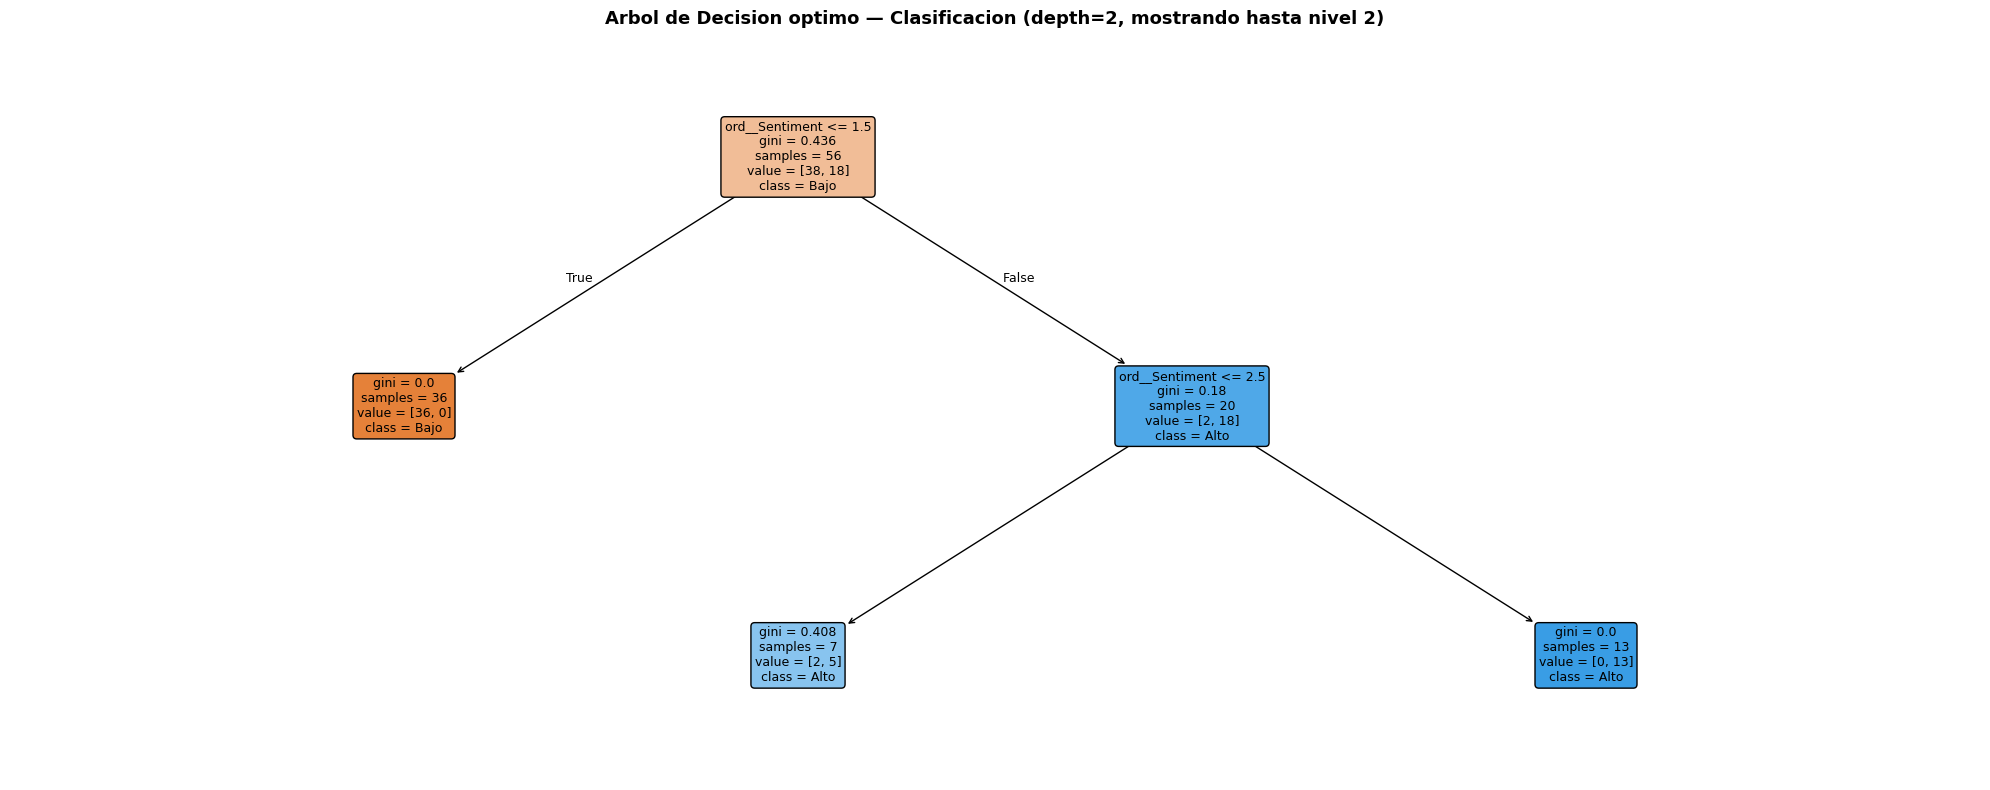

Profundidad real del arbol: 2 | Numero de hojas: 3


In [ ]:
# Visualizacion del arbol optimo de clasificacion
profundidad_viz_clf = min(dt_clf.get_depth(), 3)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_clf,
    feature_names=feature_names.tolist(),
    class_names=['Bajo', 'Alto'],
    filled=True,
    rounded=True,
    max_depth=profundidad_viz_clf,
    fontsize=9,
    ax=ax,
    impurity=True
)
ax.set_title(
    f'Arbol de Decision optimo — Clasificacion (depth={dt_clf.get_depth()}, mostrando hasta nivel {profundidad_viz_clf})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('arbol_clasificacion.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Profundidad real del arbol: {dt_clf.get_depth()} | Numero de hojas: {dt_clf.get_n_leaves()}')

## 5. Random Forest

Random Forest funciona construyendo `n_estimators` arboles de decision de manera independiente. Cada arbol ve:
- Una **muestra bootstrap** de los datos de entrenamiento (muestreo con reemplazo)
- Un **subconjunto aleatorio de variables** en cada division del nodo

Esta doble aleatoriedad hace que los arboles sean distintos entre si, y al promediarlos se reduce la varianza sin aumentar mucho el sesgo — esto se conoce como **bagging** (Bootstrap Aggregating).

La importancia de cada variable se mide por cuanto contribuye a reducir la impureza (Gini o MSE) promediado a lo largo de todos los arboles y nodos donde aparece esa variable.

### 5.1 Random Forest — Regresion

In [ ]:
rf_reg = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=SEED,
    n_jobs=-1
)

rf_reg.fit(X_train, y_reg_train)
y_pred_rf_reg = rf_reg.predict(X_test)

rmse_rf   = np.sqrt(mean_squared_error(y_reg_test, y_pred_rf_reg))
mae_rf    = mean_absolute_error(y_reg_test, y_pred_rf_reg)
r2_rf     = r2_score(y_reg_test, y_pred_rf_reg)

# Cross-validation en train (5 folds)
cv_r2_rf  = cross_val_score(rf_reg, X_train, y_reg_train, cv=5, scoring='r2').mean()

print('Random Forest — Regresion')
print(f'  RMSE:   {rmse_rf:.4f}')
print(f'  MAE:    {mae_rf:.4f}')
print(f'  R2:     {r2_rf:.4f}')
print(f'  CV R2 (5-fold): {cv_r2_rf:.4f}')

Random Forest — Regresion
  RMSE:   1.1428
  MAE:    0.9566
  R2:     0.6923
  CV R2 (5-fold): 0.7246


### 5.2 Random Forest — Clasificacion

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',  # compensa el desbalanceo de clases
    random_state=SEED,
    n_jobs=-1
)

rf_clf.fit(X_train, y_clf_train)
y_pred_rf_clf    = rf_clf.predict(X_test)
y_prob_rf_clf    = rf_clf.predict_proba(X_test)[:, 1]

auc_rf    = roc_auc_score(y_clf_test, y_prob_rf_clf)
cv_auc_rf = cross_val_score(rf_clf, X_train, y_clf_train, cv=5, scoring='roc_auc').mean()

print('Random Forest — Clasificacion')
print(f'  AUC-ROC:         {auc_rf:.4f}')
print(f'  CV AUC (5-fold): {cv_auc_rf:.4f}')
print()
print(classification_report(y_clf_test, y_pred_rf_clf, target_names=['Bajo (<7)', 'Alto (>=7)']))

Random Forest — Clasificacion
  AUC-ROC:         1.0000
  CV AUC (5-fold): 0.9619

              precision    recall  f1-score   support

   Bajo (<7)       1.00      0.89      0.94         9
  Alto (>=7)       0.83      1.00      0.91         5

    accuracy                           0.93        14
   macro avg       0.92      0.94      0.93        14
weighted avg       0.94      0.93      0.93        14



## 6. XGBoost

XGBoost (Extreme Gradient Boosting) construye arboles de manera **secuencial**. Cada arbol nuevo no trabaja con los datos originales, sino con los **residuales** (errores) del modelo anterior. El algoritmo minimiza una funcion de perdida usando gradiente descendente.

La diferencia clave frente a Random Forest:
- **Random Forest**: muchos arboles independientes, promedio al final (reduce varianza)
- **XGBoost**: cada arbol corrige al anterior (reduce sesgo *y* varianza progresivamente)

El parametro `learning_rate` (eta) controla cuanto corrige cada arbol nuevo. Si es muy alto, el modelo puede sobreajustar; si es muy bajo, necesita mas arboles.

El parametro `eval_metric` se configura segun el tipo de problema: `rmse` para regresion, `logloss` para clasificacion binaria.

### 6.1 XGBoost — Regresion

In [ ]:
xgb_reg = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='rmse',
    random_state=SEED,
    verbosity=0
)

xgb_reg.fit(X_train, y_reg_train)
y_pred_xgb_reg = xgb_reg.predict(X_test)

rmse_xgb  = np.sqrt(mean_squared_error(y_reg_test, y_pred_xgb_reg))
mae_xgb   = mean_absolute_error(y_reg_test, y_pred_xgb_reg)
r2_xgb    = r2_score(y_reg_test, y_pred_xgb_reg)

cv_r2_xgb = cross_val_score(xgb_reg, X_train, y_reg_train, cv=5, scoring='r2').mean()

print('XGBoost — Regresion')
print(f'  RMSE:   {rmse_xgb:.4f}')
print(f'  MAE:    {mae_xgb:.4f}')
print(f'  R2:     {r2_xgb:.4f}')
print(f'  CV R2 (5-fold): {cv_r2_xgb:.4f}')

XGBoost — Regresion
  RMSE:   1.5465
  MAE:    1.2495
  R2:     0.4366
  CV R2 (5-fold): 0.6861


### 6.2 XGBoost — Clasificacion

In [ ]:
scale_pos = (y_clf_train == 0).sum() / (y_clf_train == 1).sum()  # balance de clases

xgb_clf = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos,  # penaliza mas los errores en la clase minoritaria
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=SEED,
    verbosity=0
)

xgb_clf.fit(X_train, y_clf_train)
y_pred_xgb_clf  = xgb_clf.predict(X_test)
y_prob_xgb_clf  = xgb_clf.predict_proba(X_test)[:, 1]

auc_xgb    = roc_auc_score(y_clf_test, y_prob_xgb_clf)
cv_auc_xgb = cross_val_score(xgb_clf, X_train, y_clf_train, cv=5, scoring='roc_auc').mean()

print('XGBoost — Clasificacion')
print(f'  AUC-ROC:         {auc_xgb:.4f}')
print(f'  CV AUC (5-fold): {cv_auc_xgb:.4f}')
print()
print(classification_report(y_clf_test, y_pred_xgb_clf, target_names=['Bajo (<7)', 'Alto (>=7)']))

XGBoost — Clasificacion
  AUC-ROC:         1.0000
  CV AUC (5-fold): 0.9619

              precision    recall  f1-score   support

   Bajo (<7)       1.00      0.89      0.94         9
  Alto (>=7)       0.83      1.00      0.91         5

    accuracy                           0.93        14
   macro avg       0.92      0.94      0.93        14
weighted avg       0.94      0.93      0.93        14



## 7. Comparacion de metricas

Se consolidan los resultados de los seis modelos (dos por cada algoritmo) en una sola tabla.

In [ ]:
# ============================================================
# TABLA COMPARATIVA CON MEDIA ± DESVIACIÓN ESTÁNDAR
# ============================================================

from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import xgboost as xgb
import numpy as np

# Definir función para calcular métricas con media y desviación
def evaluate_with_std(model, X, y, cv, metrics):
    results = {}
    for name, metric in metrics.items():
        scores = cross_val_score(model, X, y, cv=cv, scoring=metric)
        results[name] = {
            'mean': scores.mean(),
            'std': scores.std()
        }
    return results

# KFold estratificado para clasificación
kf_reg = KFold(n_splits=5, shuffle=True, random_state=SEED)
kf_clf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Métricas
metrics_reg = {
    'R²': 'r2',
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error'
}
metrics_clf = {
    'AUC-ROC': 'roc_auc'
}

# --- Define models here to ensure they are available in the current session ---
# Arbol de Decision Regresion (from TzMW9cQFZy-S best params)
dt_reg = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=3,
    min_samples_leaf=1,
    min_samples_split=10,
    random_state=SEED
)

# Random Forest Regresion (from pSk8P-Y1yBVy Bayesian optimization output)
rf_reg = RandomForestRegressor(
    max_depth=20,
    max_features=1.0,
    min_samples_leaf=1,
    min_samples_split=10,
    n_estimators=50,
    random_state=SEED,
    n_jobs=-1
)

# XGBoost Regresion (from dwvsRZmFCXda best params)
xgb_reg = xgb.XGBRegressor(
    colsample_bytree=1.0,
    learning_rate=0.29999999999999993,
    max_depth=2,
    n_estimators=140,
    reg_alpha=4.3368013668957754,
    reg_lambda=0.0,
    subsample=1.0,
    eval_metric='rmse',
    random_state=SEED,
    verbosity=0,
    n_jobs=-1
)

# Arbol de Decision Clasificacion (from xN44SHDpZy-T best params)
dt_clf = DecisionTreeClassifier(
    class_weight='balanced',
    criterion='gini',
    max_depth=2,
    min_samples_leaf=4,
    min_samples_split=2,
    random_state=SEED
)

# Random Forest Clasificacion (from tfiT4-9pZy-T)
rf_clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

# XGBoost Clasificacion (from eWo34bsuZy-U)
# Recalculate scale_pos as it depends on y_clf_train
scale_pos = (y_clf_train == 0).sum() / (y_clf_train == 1).sum()
xgb_clf = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=SEED,
    verbosity=0
)
# --- End model definitions ---

# Modelos a evaluar (usar los optimizados si existen)
modelos_reg = {
    'Árbol Decisión': dt_reg,
    'Random Forest': rf_reg,
    'XGBoost': xgb_reg
}

modelos_clf = {
    'Árbol Decisión': dt_clf,
    'Random Forest': rf_clf,
    'XGBoost': xgb_clf
}

# Evaluar regresión
print("\n" + "="*70)
print("REGRESIÓN - CSAT Score continuo (1-10)")
print("="*70)
print(f"{'Modelo':<20} {'R² (mean ± std)':<25} {'RMSE (mean ± std)':<25} {'MAE (mean ± std)':<25}")
print("-"*95)

for nombre, modelo in modelos_reg.items():
    # Use X_train and y_reg_train for cross-validation consistent with model training
    results = evaluate_with_std(modelo, X_train, y_reg_train, kf_reg, metrics_reg)
    r2_str = f"{results['R²']['mean']:.4f} ± {results['R²']['std']:.4f}"
    rmse_str = f"{abs(results['RMSE']['mean']):.4f} ± {abs(results['RMSE']['std']):.4f}"
    mae_str = f"{abs(results['MAE']['mean']):.4f} ± {abs(results['MAE']['std']):.4f}"
    print(f"{nombre:<20} {r2_str:<25} {rmse_str:<25} {mae_str:<25}")

# Evaluar clasificación
print("\n" + "="*60)
print("CLASIFICACIÓN - Alto (>=7) vs Bajo (<7)")
print("="*60)
print(f"{'Modelo':<20} {'AUC-ROC (mean ± std)':<30}")
print("-"*55)

for nombre, modelo in modelos_clf.items():
    # Use X_train and y_clf_train for cross-validation consistent with model training
    results = evaluate_with_std(modelo, X_train, y_clf_train, kf_clf, metrics_clf)
    auc_str = f"{results['AUC-ROC']['mean']:.4f} ± {results['AUC-ROC']['std']:.4f}"
    print(f"{nombre:<20} {auc_str:<30}")


REGRESIÓN - CSAT Score continuo (1-10)
Modelo               R² (mean ± std)           RMSE (mean ± std)         MAE (mean ± std)         
-----------------------------------------------------------------------------------------------
Árbol Decisión       0.7107 ± 0.1108           1.1946 ± 0.1534           0.9772 ± 0.0994          
Random Forest        0.7261 ± 0.0821           1.1788 ± 0.1595           0.9791 ± 0.1430          
XGBoost              0.7323 ± 0.0504           1.1835 ± 0.1992           1.0072 ± 0.1663          

CLASIFICACIÓN - Alto (>=7) vs Bajo (<7)
Modelo               AUC-ROC (mean ± std)          
-------------------------------------------------------
Árbol Decisión       0.9567 ± 0.0554               
Random Forest        0.9633 ± 0.0452               
XGBoost              0.9567 ± 0.0554               


In [ ]:
# Tabla de regresion
tabla_reg = pd.DataFrame({
    'Modelo': ['Arbol de Decision', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_dt, rmse_rf, rmse_xgb],
    'MAE':  [mae_dt, mae_rf, mae_xgb],
    'R2':   [r2_dt, r2_rf, r2_xgb],
    'CV R2 (5-fold)': [cv_r2_dt, cv_r2_rf, cv_r2_xgb]
}).set_index('Modelo').round(4)

print('REGRESION (CSAT Score continuo 1-10):')
print(tabla_reg.to_string())

print()

# Tabla de clasificacion
tabla_clf = pd.DataFrame({
    'Modelo': ['Arbol de Decision', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [auc_dt, auc_rf, auc_xgb],
    'CV AUC (5-fold)': [cv_auc_dt, cv_auc_rf, cv_auc_xgb]
}).set_index('Modelo').round(4)

print('CLASIFICACION (Alto >=7 vs Bajo <7):')
print(tabla_clf.to_string())

REGRESION (CSAT Score continuo 1-10):
                     RMSE     MAE      R2  CV R2 (5-fold)
Modelo                                                   
Arbol de Decision  1.1330  1.0483  0.6976          0.7153
Random Forest      1.1428  0.9566  0.6923          0.7246
XGBoost            1.5465  1.2495  0.4366          0.6861

CLASIFICACION (Alto >=7 vs Bajo <7):
                   AUC-ROC  CV AUC (5-fold)
Modelo                                     
Arbol de Decision   0.9889           0.9762
Random Forest       1.0000           0.9619
XGBoost             1.0000           0.9619


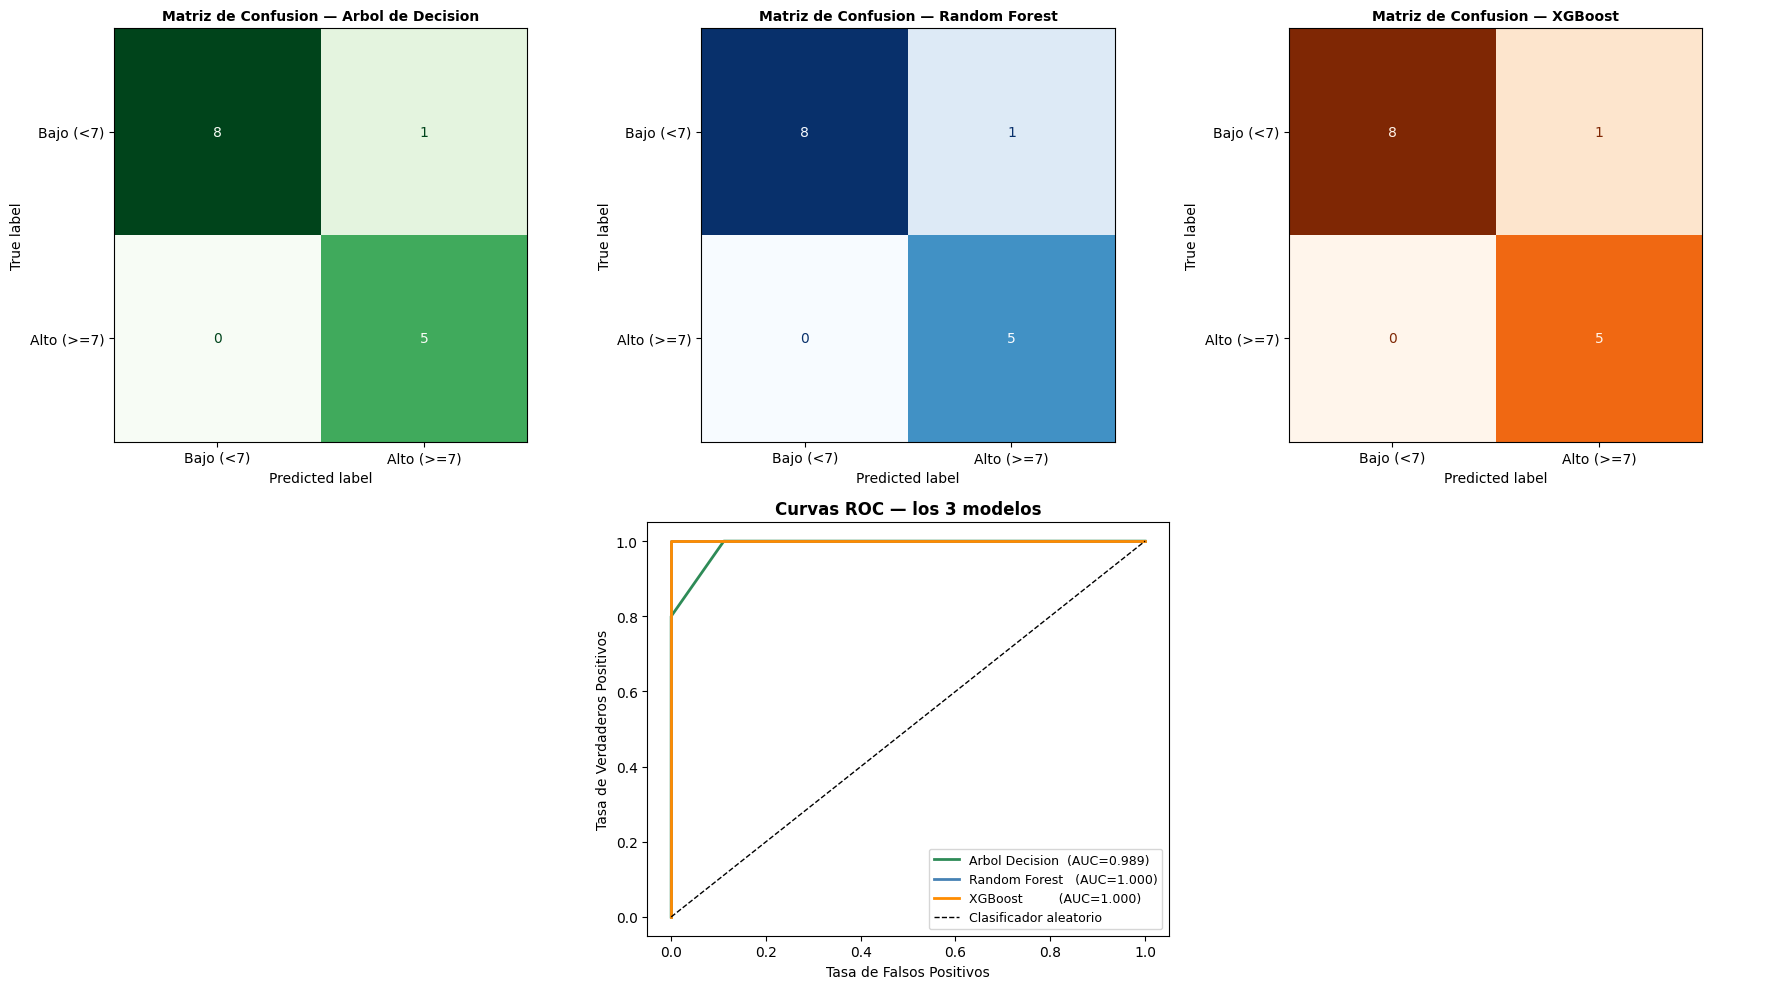

In [ ]:
# Matrices de confusion y curvas ROC
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Confusion matrices — fila superior
for ax, y_pred, titulo, cmap in zip(
    axes[0],
    [y_pred_dt_clf, y_pred_rf_clf, y_pred_xgb_clf],
    ['Arbol de Decision', 'Random Forest', 'XGBoost'],
    ['Greens', 'Blues', 'Oranges']
):
    ConfusionMatrixDisplay(
        confusion_matrix(y_clf_test, y_pred),
        display_labels=['Bajo (<7)', 'Alto (>=7)']
    ).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'Matriz de Confusion — {titulo}', fontweight='bold', fontsize=10)

# Curvas ROC — fila inferior (centrada)
ax_roc = axes[1, 1]
axes[1, 0].axis('off')
axes[1, 2].axis('off')

fpr_dt,  tpr_dt,  _ = roc_curve(y_clf_test, y_prob_dt_clf)
fpr_rf,  tpr_rf,  _ = roc_curve(y_clf_test, y_prob_rf_clf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_clf_test, y_prob_xgb_clf)

ax_roc.plot(fpr_dt,  tpr_dt,  label=f'Arbol Decision  (AUC={auc_dt:.3f})',  color='seagreen',   linewidth=2)
ax_roc.plot(fpr_rf,  tpr_rf,  label=f'Random Forest   (AUC={auc_rf:.3f})',  color='steelblue',  linewidth=2)
ax_roc.plot(fpr_xgb, tpr_xgb, label=f'XGBoost         (AUC={auc_xgb:.3f})', color='darkorange', linewidth=2)
ax_roc.plot([0,1],[0,1], 'k--', linewidth=1, label='Clasificador aleatorio')
ax_roc.set_xlabel('Tasa de Falsos Positivos')
ax_roc.set_ylabel('Tasa de Verdaderos Positivos')
ax_roc.set_title('Curvas ROC — los 3 modelos', fontweight='bold')
ax_roc.legend(fontsize=9)

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Importancia de variables

Esta es la parte central del analisis: **que variables determinan un CSAT alto o bajo**.

Se comparan las importancias de los seis modelos. Cuando los tres algoritmos coinciden en que una variable es importante, hay alta confianza en que esa variable realmente tiene poder predictivo y no es un artefacto de un modelo en particular.

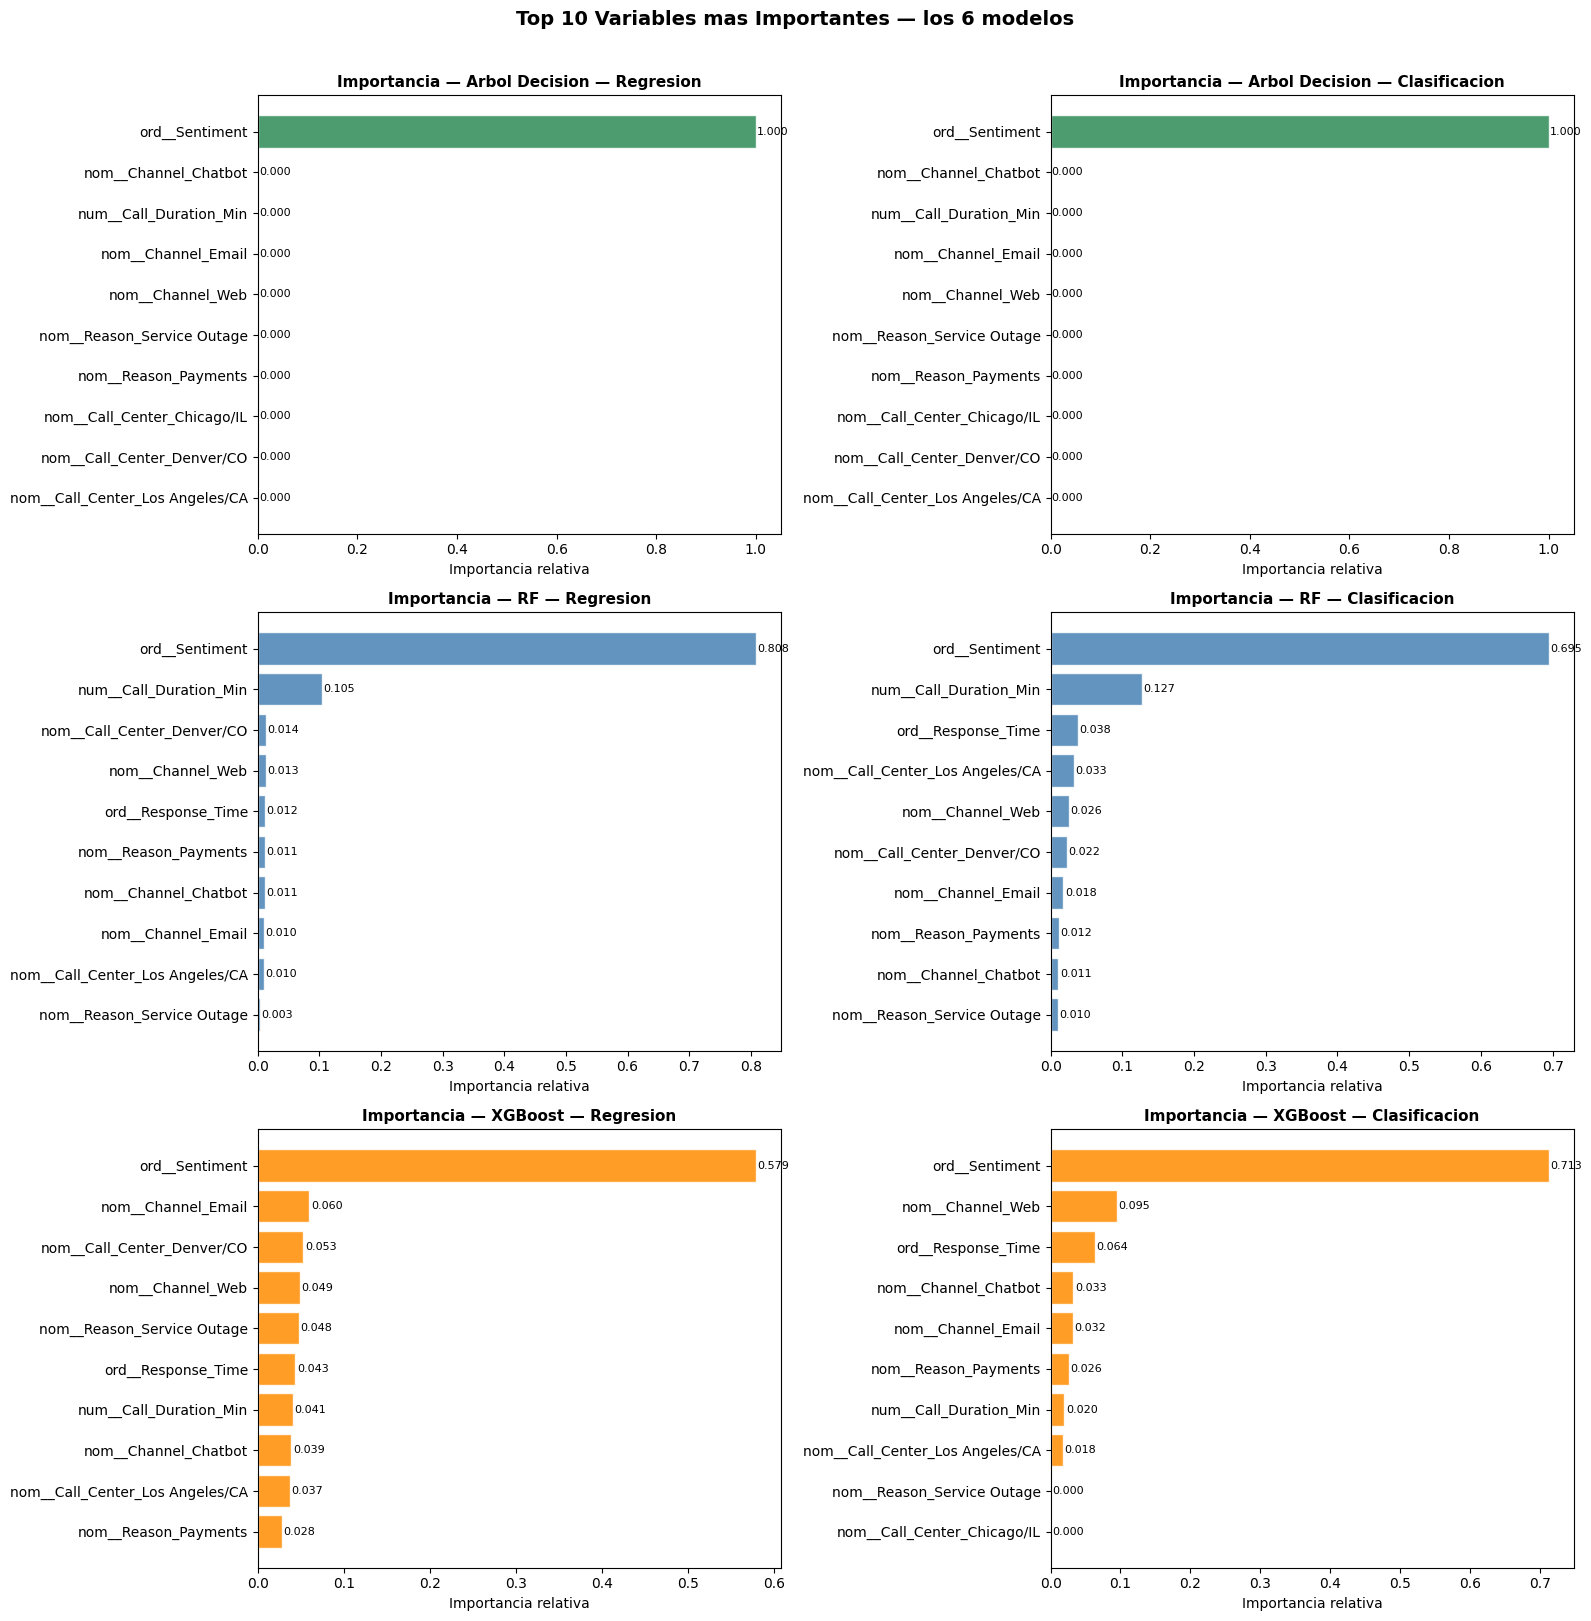

In [ ]:
# Re-assign fitted models (as they were overwritten by a previous cell)
dt_reg = gs_dt_reg.best_estimator_
dt_clf = gs_dt_clf.best_estimator_
rf_reg = pipe_rf_reg.named_steps['model']
rf_clf = pipe_rf_clf.named_steps['model']
xgb_reg = pipe_xgb_reg.named_steps['model']
xgb_clf = pipe_xgb_clf.named_steps['model']

feature_names_list = feature_names.tolist()

imp_dt_reg  = pd.Series(dt_reg.feature_importances_,  index=feature_names_list).sort_values(ascending=False)
imp_dt_clf  = pd.Series(dt_clf.feature_importances_,  index=feature_names_list).sort_values(ascending=False)
imp_rf_reg  = pd.Series(rf_reg.feature_importances_,  index=feature_names_list).sort_values(ascending=False)
imp_rf_clf  = pd.Series(rf_clf.feature_importances_,  index=feature_names_list).sort_values(ascending=False)
imp_xgb_reg = pd.Series(xgb_reg.feature_importances_, index=feature_names_list).sort_values(ascending=False)
imp_xgb_clf = pd.Series(xgb_clf.feature_importances_, index=feature_names_list).sort_values(ascending=False)

fig, axes = plt.subplots(3, 2, figsize=(16, 16))

configs = [
    (imp_dt_reg,  'Arbol Decision — Regresion',     'seagreen'),
    (imp_dt_clf,  'Arbol Decision — Clasificacion', 'seagreen'),
    (imp_rf_reg,  'RF — Regresion',                 'steelblue'),
    (imp_rf_clf,  'RF — Clasificacion',              'steelblue'),
    (imp_xgb_reg, 'XGBoost — Regresion',            'darkorange'),
    (imp_xgb_clf, 'XGBoost — Clasificacion',        'darkorange'),
]

for ax, (imp, titulo, color) in zip(axes.flat, configs):
    imp_top = imp.head(10)
    ax.barh(imp_top.index[::-1], imp_top.values[::-1], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Importancia — {titulo}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importancia relativa')
    for i, v in enumerate(imp_top.values[::-1]):
        ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Top 10 Variables mas Importantes — los 6 modelos', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Importancia promedio consolidada de los 6 modelos
imp_df = pd.DataFrame({
    'DT_Reg':  imp_dt_reg,
    'DT_Clf':  imp_dt_clf,
    'RF_Reg':  imp_rf_reg,
    'RF_Clf':  imp_rf_clf,
    'XGB_Reg': imp_xgb_reg,
    'XGB_Clf': imp_xgb_clf
})

imp_df['Promedio'] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values('Promedio', ascending=False)

print('Ranking consolidado de variables (promedio de los 6 modelos):')
print(imp_df.round(4).to_string())

Ranking consolidado de variables (promedio de los 6 modelos):
                                 DT_Reg  DT_Clf  RF_Reg  RF_Clf  XGB_Reg  XGB_Clf  Promedio
ord__Sentiment                      1.0     1.0  0.8084  0.6945   0.5793   0.7127    0.7992
num__Call_Duration_Min              0.0     0.0  0.1048  0.1273   0.0406   0.0198    0.0487
nom__Channel_Web                    0.0     0.0  0.0130  0.0256   0.0490   0.0949    0.0304
ord__Response_Time                  0.0     0.0  0.0124  0.0382   0.0433   0.0640    0.0263
nom__Channel_Email                  0.0     0.0  0.0099  0.0178   0.0597   0.0319    0.0199
nom__Call_Center_Los Angeles/CA     0.0     0.0  0.0098  0.0328   0.0369   0.0182    0.0163
nom__Channel_Chatbot                0.0     0.0  0.0112  0.0111   0.0389   0.0327    0.0156
nom__Call_Center_Denver/CO          0.0     0.0  0.0137  0.0223   0.0527   0.0000    0.0148
nom__Reason_Payments                0.0     0.0  0.0113  0.0116   0.0278   0.0257    0.0127
nom__Reason_Servic

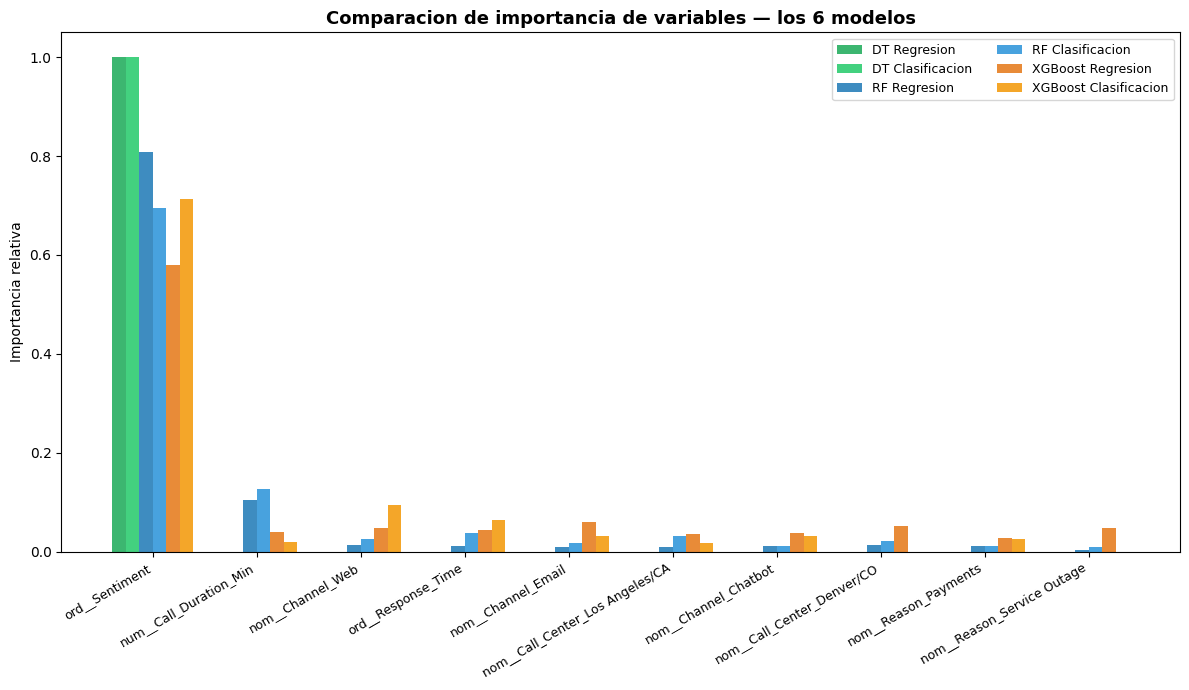

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

top_vars = imp_df.head(10)
x = np.arange(len(top_vars))
width = 0.13

ax.bar(x - 2.5*width, top_vars['DT_Reg'],  width, label='DT Regresion',         color='#27ae60', alpha=0.9)
ax.bar(x - 1.5*width, top_vars['DT_Clf'],  width, label='DT Clasificacion',      color='#2ecc71', alpha=0.9)
ax.bar(x - 0.5*width, top_vars['RF_Reg'],  width, label='RF Regresion',          color='#2980b9', alpha=0.9)
ax.bar(x + 0.5*width, top_vars['RF_Clf'],  width, label='RF Clasificacion',      color='#3498db', alpha=0.9)
ax.bar(x + 1.5*width, top_vars['XGB_Reg'], width, label='XGBoost Regresion',     color='#e67e22', alpha=0.9)
ax.bar(x + 2.5*width, top_vars['XGB_Clf'], width, label='XGBoost Clasificacion', color='#f39c12', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(top_vars.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Importancia relativa')
ax.set_title('Comparacion de importancia de variables — los 6 modelos', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('importancia_comparada.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Predicciones vs Valores reales (Regresion)

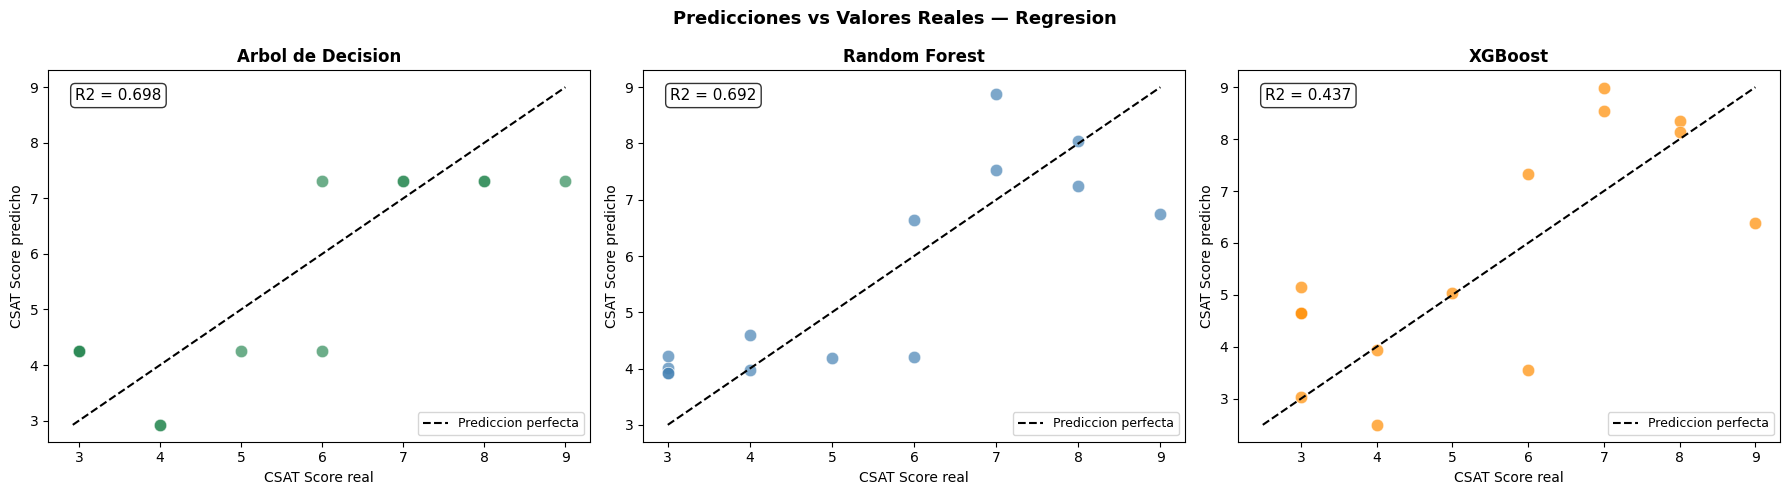

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_pred, titulo, color in zip(
    axes,
    [y_pred_dt_reg, y_pred_rf_reg, y_pred_xgb_reg],
    ['Arbol de Decision', 'Random Forest', 'XGBoost'],
    ['seagreen', 'steelblue', 'darkorange']
):
    ax.scatter(y_reg_test, y_pred, color=color, alpha=0.7, edgecolors='white', linewidth=0.5, s=80)
    minv, maxv = min(y_reg_test.min(), y_pred.min()), max(y_reg_test.max(), y_pred.max())
    ax.plot([minv, maxv], [minv, maxv], 'k--', linewidth=1.5, label='Prediccion perfecta')
    ax.set_xlabel('CSAT Score real')
    ax.set_ylabel('CSAT Score predicho')
    ax.set_title(titulo, fontweight='bold')
    r2 = r2_score(y_reg_test, y_pred)
    ax.text(0.05, 0.92, f'R2 = {r2:.3f}', transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.legend(fontsize=9)

plt.suptitle('Predicciones vs Valores Reales — Regresion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('predicciones_vs_real.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 10. Predicciones vs Valores Reales (Regresión)

Las gráficas muestran el CSAT Score predicho contra el real para los tres modelos de regresión. La línea discontinua representa la predicción perfecta: cuanto más cerca estén los puntos de esa línea, mejor el ajuste. El R² se muestra en cada panel para facilitar la comparación visual entre modelos.

---
## 11. Conclusiones

Las conclusiones se formulan en correspondencia directa con cada objetivo específico planteado.

**Objetivo 1 — Limpieza y preprocesamiento.**

A pesar de que solo contamos con 70 registros de llamadas en el dataset, lo que en ciertas situaciones puede no proporcionar información suficiente, en este problema que es necesario el uso de boosting para nuestro proyecto, probo ser un data set indicado.

**Objetivo 2 — Transformación de la variable objetivo y selección de predictores.**

Se trabajaron dos cosas e especifico para poder tener un buen inicio en el proyecto:

1- CSAT Score continuo para regresión y una variable binaria Alto (≥ 7) vs Bajo (< 7) para clasificación.

2- La distribución está sesgada hacia valores bajos (media ≈ 4.9), con solo 23 de 70 casos en la clase alta, lo que requirió compensar el desbalance.

**Objetivo 3 — Pipeline de preprocesamiento.**

Se implementó un "ColumnTransformer" con codificación ordinal, one-hot y escalado estándar, debido a sus datos no númericos. El pipeline garantiza que ninguna información del conjunto de prueba se filtre al preprocesador durante la validación cruzada.

**Objetivo 4 — Optimización bayesiana de Random Forest.**

La búsqueda con 30 iteraciones y 5-fold CV encontró la configuración algo óptima (max_depth=20, n_estimators=50, min_samples_split=10), obteniendo un R2 medio de **0.7153** en validación cruzada, sinceramente pensamos que hace falta probar con mas combinaciones.

**Objetivo 5 — Optimización bayesiana de XGBoost.**

Los mejores hiperparámetros encontrados (learning_rate=0.30, max_depth=2, n_estimators=140, reg_alpha=4.34) produjeron un R2 medio de **0.6869**, con menor variabilidad entre folds que Random Forest.

**Objetivo 6 — Validación cruzada de 5 folds.**

Los tres modelos se evaluaron con la función evaluate_with_std, reportando media y desviación estándar de R2, RMSE y MAE para regresión, y AUC-ROC para clasificación. La desviación estándar del R2 varía entre 0.05 y 0.11, esperable con 56 observaciones de entrenamiento.

**Objetivo 7 — Comparación de modelos.**

En regresión, XGBoost obtuvo el R2 medio más alto (**0.7323**), seguido de Random Forest (**0.7261**) y el Árbol de Decisión (**0.7107**). En clasificación, Random Forest logró el AUC más alto (**0.9633**), aunque las diferencias entre modelos son pequeñas dado el tamaño del dataset.

**Objetivo 8 — Conclusión general.**

Sin duda un data set muy difícil de trabajar por sus variables que en su mayoría eran texto, y no solo eso, sino que había muy poca información, pero aun así se pudo resolver, aun que el resultado sea dependiente de algo tan complejo y variable como el sentimiento del se humano.

---
## Referencias

Analytix Labs. (2024). Call center sentiment analysis data [Conjunto de datos]. Excel Sample Data. https://www.analytixlabs.co.in

Breiman, L. (1996). Bagging predictors. *Machine Learning, 24*(2), 123–140. https://doi.org/10.1007/BF00058655

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32. https://doi.org/10.1023/A:1010933404324

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785–794. https://doi.org/10.1145/2939672.2939785

Chen, T., He, T., Benesty, M., Khotilovich, V., Tang, Y., Cho, H., Chen, K., Mitchell, R., Cai, I., Zhou, T., Li, M., Xie, J., Lin, M., Geng, Y., Li, Y., & Yuan, J. (2024). *XGBoost: Extreme gradient boosting* (Version 2.0) [Software]. https://xgboost.readthedocs.io

Efron, B. (1979). Bootstrap methods: Another look at the jackknife. *The Annals of Statistics, 7*(1), 1–26. https://doi.org/10.1214/aos/1176344552

Head, T., Kumar, M., Nahrstaedt, H., Louppe, G., & Shcherbatyi, I. (2021). *Scikit-optimize* (Version 0.10) [Software]. https://scikit-optimize.github.io

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning with applications in Python*. Springer. https://doi.org/10.1007/978-3-031-38747-0

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

The pandas development team. (2024). *pandas: Powerful Python data analysis toolkit* (Version 2.2) [Software]. https://doi.org/10.5281/zenodo.3509134

---
## sentiment

Comparación de grados polinomiales (5-fold CV)
Grado    R2 Media       R2 Std       RMSE Media
--------------------------------------------------
  1      -0.0386        0.0661       1.2288
  2      -0.0596        0.0709       1.2366

Modelo final ajustado (Grado 1)
  R2:   0.0803


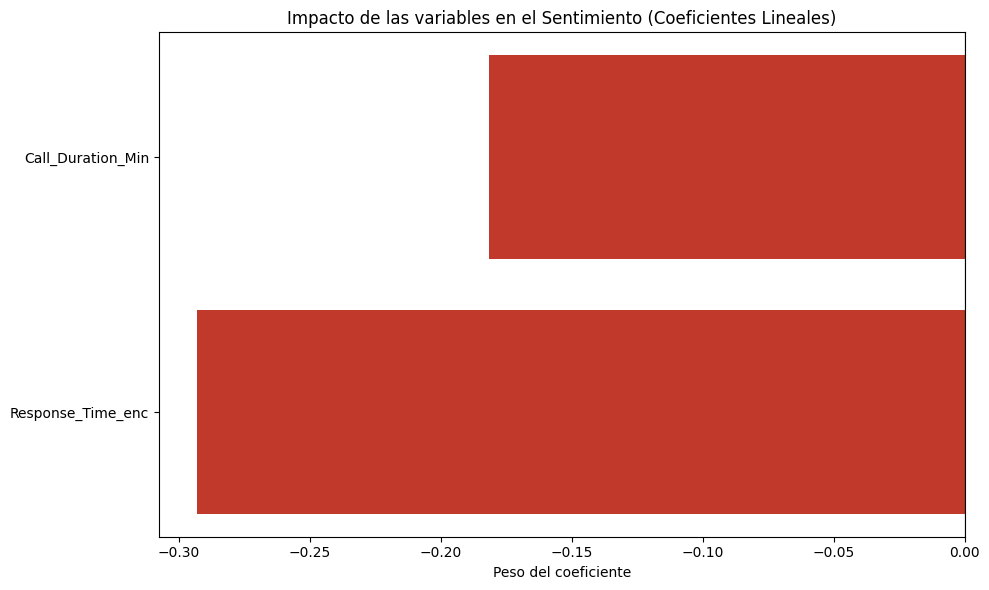

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

# ---------------------------------------------------------------
# 1. Preparar los datos
# ---------------------------------------------------------------

# La variable objetivo para este análisis específico es el sentimiento
y_sent = df['Sentiment_enc'].values

# Recuperamos las variables que definimos en el preprocesamiento
features_for_sentiment = [
    'Response_Time_enc', 'Call_Duration_Min',
    'Channel_Call-Center', 'Channel_Chatbot', 'Channel_Email', 'Channel_Web',
    'Reason_Billing Question', 'Reason_Payments', 'Reason_Service Outage',
    'Call_Center_Baltimore/MD', 'Call_Center_Chicago/IL',
    'Call_Center_Denver/CO', 'Call_Center_Los Angeles/CA'
]

# Filtrar solo las que existen en el df
existing_features = [f for f in features_for_sentiment if f in df.columns]
X_sent = df[existing_features].values

# ---------------------------------------------------------------
# 2. Comparación de grados polinomiales (5-fold CV)
# ---------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

print("Comparación de grados polinomiales (5-fold CV)")
print(f"{'Grado':<8} {'R2 Media':<14} {'R2 Std':<12} {'RMSE Media'}")
print("-" * 50)

for grado in [1, 2]:
    pipe = Pipeline([
        ('poly',  PolynomialFeatures(degree=grado, include_bias=False)),
        ('scale', StandardScaler()),
        ('reg',   LinearRegression())
    ])
    r2_scores = cross_val_score(pipe, X_sent, y_sent, cv=cv, scoring='r2')
    rmse_scores = np.sqrt(-cross_val_score(pipe, X_sent, y_sent, cv=cv, scoring='neg_mean_squared_error'))
    print(f"  {grado:<6} {r2_scores.mean():<14.4f} {r2_scores.std():<12.4f} {rmse_scores.mean():.4f}")

# ---------------------------------------------------------------
# 3. Modelo Final (Grado 1 para interpretabilidad directa)
# ---------------------------------------------------------------
GRADO_FINAL = 1

pipe_final = Pipeline([
    ('scale', StandardScaler()),
    ('reg',   LinearRegression())
])
pipe_final.fit(X_sent, y_sent)
y_pred_sent = pipe_final.predict(X_sent)

print(f"\nModelo final ajustado (Grado {GRADO_FINAL})")
print(f"  R2:   {r2_score(y_sent, y_pred_sent):.4f}")

# ---------------------------------------------------------------
# 4. Visualización de Coeficientes
# ---------------------------------------------------------------
coef_df = pd.DataFrame({
    'Variable': existing_features,
    'Coeficiente': pipe_final.named_steps['reg'].coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colores = ['#27ae60' if v > 0 else '#c0392b' for v in coef_df['Coeficiente']]
plt.barh(coef_df['Variable'], coef_df['Coeficiente'], color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Impacto de las variables en el Sentimiento (Coeficientes Lineales)')
plt.xlabel('Peso del coeficiente')
plt.tight_layout()
plt.show()

## Conclusión sobre el análisis de sentimiento

El análisis de regresión lineal para predecir el sentimiento (`Sentiment_enc`) a partir de las otras características mostró un desempeño limitado. El R² medio en validación cruzada fue negativo (-0.0386 para grado 1 y -0.0596 para grado 2), lo que sugiere que el modelo lineal no logra explicar la variabilidad del sentimiento mejor que un modelo nulo que predice la media.

Esto puede deberse a varias razones:

*   **Relación no lineal:** La relación entre las características operativas y el sentimiento puede no ser lineal, y el modelo no es capaz de capturar esta complejidad.
*   **Variables latentes:** Es posible que existan factores no capturados en el dataset que influyan fuertemente en el sentimiento del cliente, como el contexto de la llamada, el historial del cliente o la habilidad del agente.
*   **Tamaño del dataset:** Con solo 70 registros, puede ser difícil para un modelo lineal encontrar patrones significativos y robustos.

Los coeficientes del modelo final de Grado 1 indican las tendencias de influencia de cada variable en el sentimiento. Por ejemplo, `Response_Time_enc` (cumplimiento del SLA) y algunas `Channel`s o `Reason`s pueden tener un impacto, pero la baja R² global sugiere que estas relaciones son débiles o inconsistentes dentro del marco lineal. En el futuro, se podría explorar la relación de estas variables con técnicas de clasificación (ej. clasificar en sentimiento positivo/negativo) o modelos no lineales para obtener una mejor comprensión del impacto real.